# Cut Graph into 100x100 Cells and Calculate Statistics

This notebook loads the synthetic graph data, divides it into 100x100 cells based on node positions,
and calculates aggregate statistics (mean of nodes, edges, in-degree, and edge weights) across all cells.

## Notebook Structure

**PART 1: Essential Setup (MUST RUN)** - Cells 1-9
- Imports, output directory, load Graph A, define functions, assign cells

**PART 2: [OPTIONAL] Full Statistics & Visualization**
- Detailed statistics, heatmaps for Graph A & C, comparison

**PART 3: [OPTIONAL] Subgraph Analysis (y:35-55, x:45-65)**
- Extract subgraph and calculate closeness centrality

**PART 4: 5 Regions Centrality Analysis**
- Calculate closeness & betweenness centrality for 5 regions (center + 4 corners)

---
**Quick Start:** Run Part 1, then jump to Part 4 for 5 regions analysis.

In [1]:
# PART 1: Essential Setup (MUST RUN)
import pickle
from pathlib import Path
import numpy as np
import networkx as nx
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import networkit as nk  # For fast centrality calculations

# Define output directory (used throughout the notebook)
output_dir = Path("../data/output/CutGraphs/")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

Output directory: ..\data\output\CutGraphs


## Load Graph A (Essential)

In [ ]:
# Define paths to the pickle files
data_dir = Path("../data/input/tmp")

pkl_path_A = data_dir / "for will A_len1_synthetic_reindex.pkl"
pkl_path_C = data_dir / "for will C_len1_synthetic_reindex.pkl"

print(f"Loading A: {pkl_path_A}")
with open(pkl_path_A, "rb") as f:
    data_A = pickle.load(f)
G_A = data_A[0] if isinstance(data_A, list) else data_A
print(f"  Nodes: {G_A.number_of_nodes()}, Edges: {G_A.number_of_edges()}")


Loading A: ..\data\input\tmp\for will A_len1_synthetic_reindex.pkl


## Define Functions (Essential)

In [ ]:
def get_bounding_box(G):
    """Get the bounding box of the graph based on node positions."""
    positions = [G.nodes[n]['pos'] for n in G.nodes()]
    x_coords = [p[0] for p in positions]
    y_coords = [p[1] for p in positions]
    return min(x_coords), max(x_coords), min(y_coords), max(y_coords)


def assign_nodes_to_cells(G, n_cells=100):
    """
    Assign each node to a cell in a n_cells x n_cells grid.
    Returns a dictionary mapping (cell_row, cell_col) to list of nodes.
    """
    x_min, x_max, y_min, y_max = get_bounding_box(G)
    
    # Add small epsilon to avoid edge case where node is exactly at max boundary
    x_range = x_max - x_min + 1e-9
    y_range = y_max - y_min + 1e-9
    
    cell_width = x_range / n_cells
    cell_height = y_range / n_cells
    
    cell_to_nodes = defaultdict(list)
    node_to_cell = {}
    
    for node in G.nodes():
        x, y = G.nodes[node]['pos']
        cell_col = int((x - x_min) / cell_width)
        cell_row = int((y - y_min) / cell_height)
        
        # Ensure we don't exceed grid bounds
        cell_col = min(cell_col, n_cells - 1)
        cell_row = min(cell_row, n_cells - 1)
        
        cell_to_nodes[(cell_row, cell_col)].append(node)
        node_to_cell[node] = (cell_row, cell_col)
    
    return cell_to_nodes, node_to_cell, (x_min, x_max, y_min, y_max, cell_width, cell_height)

In [ ]:
def calculate_cell_statistics(G, cell_to_nodes, node_to_cell):
    """
    Calculate statistics for each cell.
    
    For each cell, we compute:
    - Number of nodes in the cell
    - Number of edges (both endpoints in the same cell)
    - Average in-degree (for undirected graph, this is degree / 2, but we use degree)
    - Average weight of edges within the cell
    
    Returns a list of dictionaries with statistics for each non-empty cell.
    """
    cell_stats = []
    
    for cell, nodes in cell_to_nodes.items():
        if len(nodes) == 0:
            continue
        
        node_set = set(nodes)
        
        # Count edges within the cell (both endpoints in cell)
        edges_in_cell = []
        for node in nodes:
            for neighbor in G.neighbors(node):
                if neighbor in node_set and node < neighbor:  # Avoid double counting
                    edges_in_cell.append((node, neighbor))
        
        num_edges = len(edges_in_cell)
        
        # Calculate average weight of edges in cell
        if num_edges > 0:
            weights = [G.edges[e]['weight'] for e in edges_in_cell]
            avg_weight = np.mean(weights)
        else:
            avg_weight = 0.0
        
        # Calculate in-degree (for undirected graphs, use degree)
        # We calculate degree considering only edges within the cell
        degrees = []
        for node in nodes:
            deg = sum(1 for neighbor in G.neighbors(node) if neighbor in node_set)
            degrees.append(deg)
        avg_in_degree = np.mean(degrees) if degrees else 0.0
        
        cell_stats.append({
            'cell': cell,
            'num_nodes': len(nodes),
            'num_edges': num_edges,
            'avg_in_degree': avg_in_degree,
            'avg_edge_weight': avg_weight
        })
    
    return cell_stats

In [ ]:
def plot_cell_heatmap(cell_to_nodes, df_stats, n_cells=100, title="Cell Statistics Heatmap", 
                      output_dir=None, prefix="graph"):
    """
    Plot heatmaps showing statistics across all cells in the 100x100 grid.
    
    Parameters:
    - cell_to_nodes: dictionary mapping cell coordinates to node lists
    - df_stats: DataFrame with cell statistics
    - n_cells: number of cells per dimension (default 100)
    - title: plot title prefix
    - output_dir: Path to save images and numpy data (optional)
    - prefix: prefix for saved filenames (e.g., 'graph_A' or 'graph_C')
    """
    # Create 2D arrays for each statistic
    num_nodes_grid = np.zeros((n_cells, n_cells))
    num_edges_grid = np.zeros((n_cells, n_cells))
    avg_degree_grid = np.zeros((n_cells, n_cells))
    avg_weight_grid = np.zeros((n_cells, n_cells))
    
    # Fill in the grids from the statistics
    for _, row in df_stats.iterrows():
        r, c = row['cell']
        num_nodes_grid[r, c] = row['num_nodes']
        num_edges_grid[r, c] = row['num_edges']
        avg_degree_grid[r, c] = row['avg_in_degree']
        avg_weight_grid[r, c] = row['avg_edge_weight']
    
    # Save numpy data if output_dir is provided
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        np.save(output_dir / f"{prefix}_num_nodes_grid.npy", num_nodes_grid)
        np.save(output_dir / f"{prefix}_num_edges_grid.npy", num_edges_grid)
        np.save(output_dir / f"{prefix}_avg_degree_grid.npy", avg_degree_grid)
        np.save(output_dir / f"{prefix}_avg_weight_grid.npy", avg_weight_grid)
        print(f"Saved numpy arrays to {output_dir}")
    
    # Plot 1: Number of nodes
    fig1, ax1 = plt.subplots(figsize=(8, 7))
    im1 = ax1.imshow(num_nodes_grid, cmap='viridis', origin='lower')
    ax1.set_title(f'{title} - Number of Nodes per Cell')
    ax1.set_xlabel('Column')
    ax1.set_ylabel('Row')
    plt.colorbar(im1, ax=ax1, label='Node Count')
    plt.tight_layout()
    if output_dir is not None:
        fig1.savefig(output_dir / f"{prefix}_num_nodes_heatmap.png", dpi=150)
    plt.show()
    
    # Plot 2: Number of edges
    fig2, ax2 = plt.subplots(figsize=(8, 7))
    im2 = ax2.imshow(num_edges_grid, cmap='viridis', origin='lower')
    ax2.set_title(f'{title} - Number of Edges per Cell')
    ax2.set_xlabel('Column')
    ax2.set_ylabel('Row')
    plt.colorbar(im2, ax=ax2, label='Edge Count')
    plt.tight_layout()
    if output_dir is not None:
        fig2.savefig(output_dir / f"{prefix}_num_edges_heatmap.png", dpi=150)
    plt.show()
    
    # Plot 3: Average in-degree
    fig3, ax3 = plt.subplots(figsize=(8, 7))
    im3 = ax3.imshow(avg_degree_grid, cmap='viridis', origin='lower')
    ax3.set_title(f'{title} - Average In-Degree per Cell')
    ax3.set_xlabel('Column')
    ax3.set_ylabel('Row')
    plt.colorbar(im3, ax=ax3, label='Avg In-Degree')
    plt.tight_layout()
    if output_dir is not None:
        fig3.savefig(output_dir / f"{prefix}_avg_degree_heatmap.png", dpi=150)
    plt.show()
    
    # Plot 4: Average edge weight
    fig4, ax4 = plt.subplots(figsize=(8, 7))
    im4 = ax4.imshow(avg_weight_grid, cmap='viridis', origin='lower')
    ax4.set_title(f'{title} - Average Edge Weight per Cell')
    ax4.set_xlabel('Column')
    ax4.set_ylabel('Row')
    plt.colorbar(im4, ax=ax4, label='Avg Weight')
    plt.tight_layout()
    if output_dir is not None:
        fig4.savefig(output_dir / f"{prefix}_avg_weight_heatmap.png", dpi=150)
    plt.show()
    
    if output_dir is not None:
        print(f"Saved heatmap images to {output_dir}")
    
    return num_nodes_grid, num_edges_grid, avg_degree_grid, avg_weight_grid

## Assign Cells to Graph A (Essential)

This creates `cell_to_nodes_A` which is needed for all subsequent analyses.

In [ ]:
print("Processing Graph A...")
print("Assigning nodes to cells...")
cell_to_nodes_A, node_to_cell_A, bbox_A = assign_nodes_to_cells(G_A, n_cells=100)

print(f"Bounding box: x=[{bbox_A[0]:.2f}, {bbox_A[1]:.2f}], y=[{bbox_A[2]:.2f}, {bbox_A[3]:.2f}]")
print(f"Cell size: {bbox_A[4]:.2f} x {bbox_A[5]:.2f}")
print(f"Number of non-empty cells: {len(cell_to_nodes_A)}")

Processing Graph A...
Assigning nodes to cells...
Bounding box: x=[-25498.49, 25501.50], y=[-25499.11, 25500.86]
Cell size: 510.00 x 510.00
Number of non-empty cells: 10000


---
# PART 2: [OPTIONAL] Full Statistics & Visualization

Skip this section if you only need the 5 Regions Analysis (Part 4).

## Graph A Statistics

In [8]:
print("Calculating cell statistics for Graph A...")
cell_stats_A = calculate_cell_statistics(G_A, cell_to_nodes_A, node_to_cell_A)
print(f"Computed statistics for {len(cell_stats_A)} cells.")

Calculating cell statistics for Graph A...
Computed statistics for 10000 cells.


In [10]:
# Calculate mean statistics across all cells for Graph A
df_A = pd.DataFrame(cell_stats_A)

print("=" * 60)
print("GRAPH A - Mean Statistics Across All Cells")
print("=" * 60)
print(f"Mean number of nodes per cell:    {df_A['num_nodes'].mean():.4f}")
print(f"Mean number of edges per cell:    {df_A['num_edges'].mean():.4f}")
print(f"Mean avg in-degree per cell:      {df_A['avg_in_degree'].mean():.4f}")
print(f"Mean avg edge weight per cell:    {df_A['avg_edge_weight'].mean():.6f}")
print("=" * 60)

GRAPH A - Mean Statistics Across All Cells
Mean number of nodes per cell:    1486.3070
Mean number of edges per cell:    1646.9641
Mean avg in-degree per cell:      2.2162
Mean avg edge weight per cell:    0.074908


In [11]:
# Show summary statistics for Graph A
print("\nDetailed Statistics for Graph A:")
df_A[['num_nodes', 'num_edges', 'avg_in_degree', 'avg_edge_weight']].describe()

# Save to CSV (output_dir defined in Part 1)
df_A.to_csv(output_dir / "graph_A_cell_stats.csv", index=False)
print(f"\nSaved Graph A statistics to {output_dir / 'graph_A_cell_stats.csv'}")


Detailed Statistics for Graph A:

Saved Graph A statistics to ..\data\output\CutGraphs\graph_A_cell_stats.csv


Plotting heatmaps for Graph A...
Saved numpy arrays to ..\data\output\CutGraphs


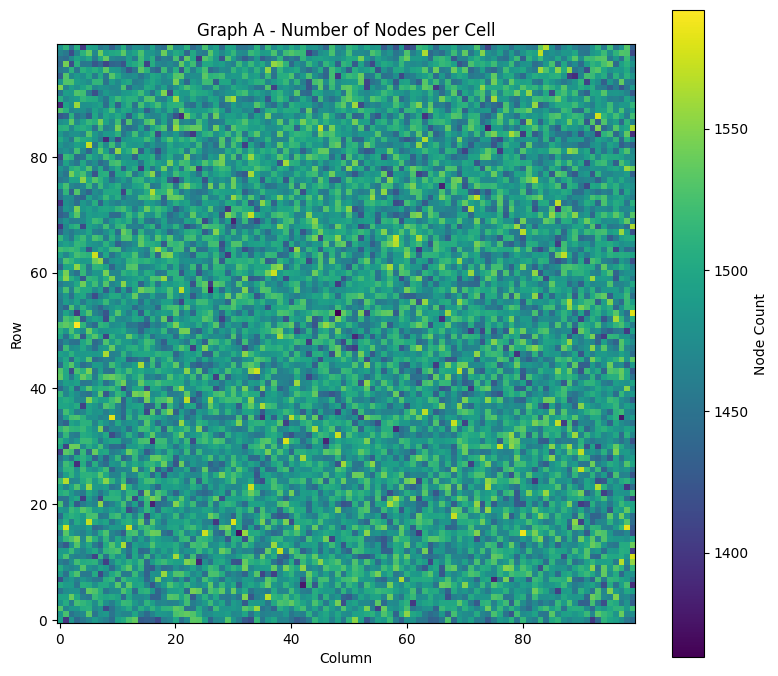

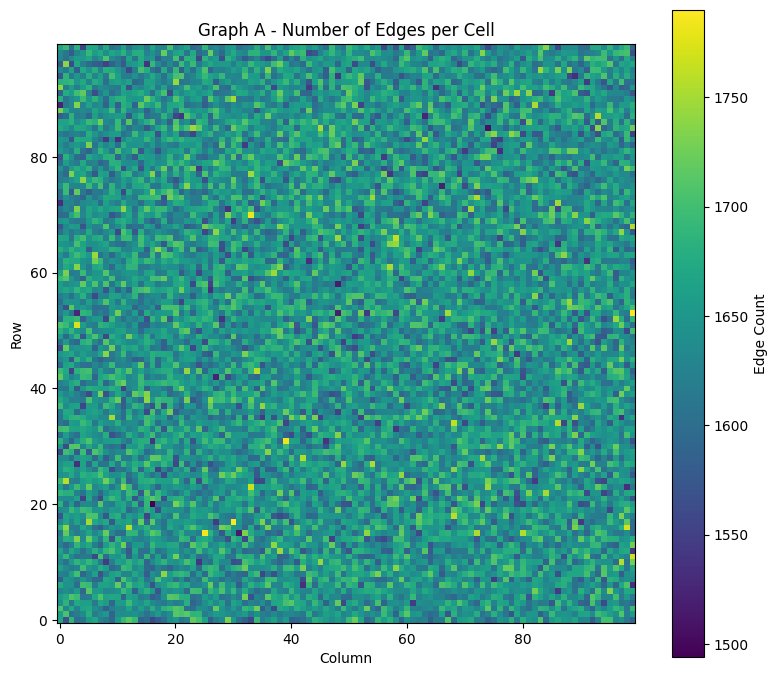

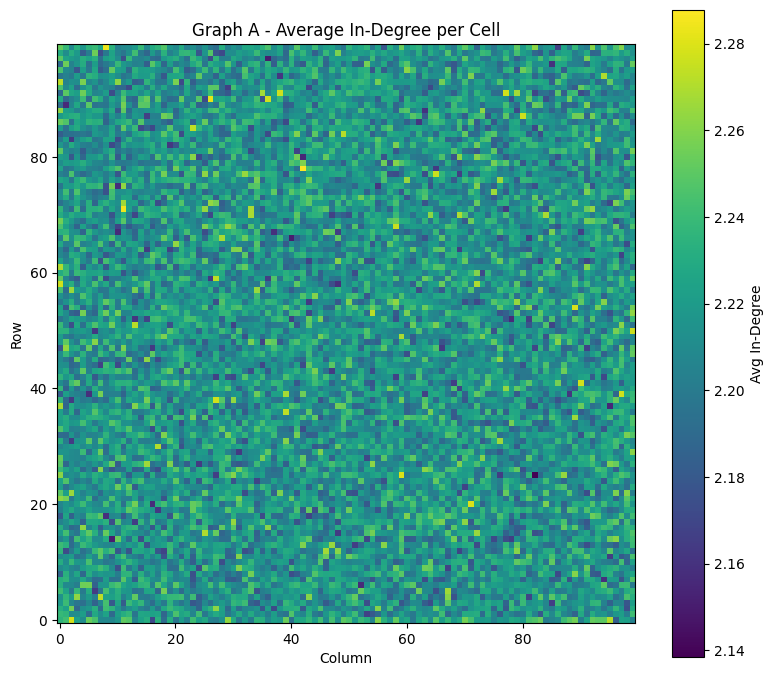

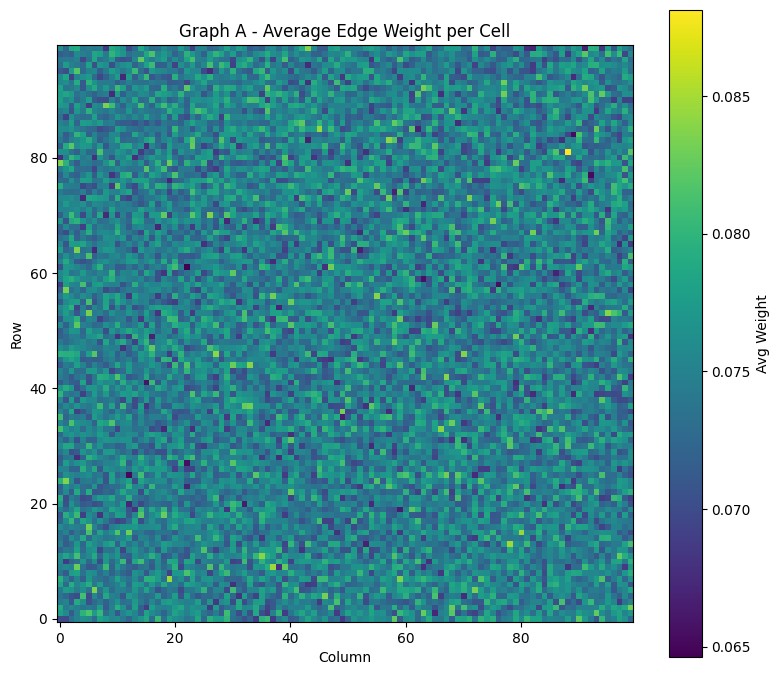

Saved heatmap images to ..\data\output\CutGraphs


In [12]:
# Visualize heatmaps for Graph A - showing all 100x100 cells
print("Plotting heatmaps for Graph A...")
grids_A = plot_cell_heatmap(cell_to_nodes_A, df_A, n_cells=100, title="Graph A", 
                            output_dir=output_dir, prefix="graph_A")

## Graph C Statistics [Optional]

In [20]:
print(f"\nLoading C: {pkl_path_C}")
with open(pkl_path_C, "rb") as f:
    data_C = pickle.load(f)
G_C = data_C[0] if isinstance(data_C, list) else data_C
print(f"  Nodes: {G_C.number_of_nodes()}, Edges: {G_C.number_of_edges()}")


Loading C: ..\data\input\tmp\for will C_len1_synthetic_reindex.pkl
  Nodes: 17773448, Edges: 20250095


In [21]:
print("Processing Graph C...")
print("Assigning nodes to cells...")
cell_to_nodes_C, node_to_cell_C, bbox_C = assign_nodes_to_cells(G_C, n_cells=100)

print(f"Bounding box: x=[{bbox_C[0]:.2f}, {bbox_C[1]:.2f}], y=[{bbox_C[2]:.2f}, {bbox_C[3]:.2f}]")
print(f"Cell size: {bbox_C[4]:.2f} x {bbox_C[5]:.2f}")
print(f"Number of non-empty cells: {len(cell_to_nodes_C)}")

Processing Graph C...
Assigning nodes to cells...
Bounding box: x=[-25500.50, 25499.50], y=[-25500.42, 25499.57]
Cell size: 510.00 x 510.00
Number of non-empty cells: 10000


In [23]:
print("Calculating cell statistics for Graph C...")
cell_stats_C = calculate_cell_statistics(G_C, cell_to_nodes_C, node_to_cell_C)
print(f"Computed statistics for {len(cell_stats_C)} cells.")

Calculating cell statistics for Graph C...
Computed statistics for 10000 cells.


In [24]:
# Calculate mean statistics across all cells for Graph C
df_C = pd.DataFrame(cell_stats_C)

print("=" * 60)
print("GRAPH C - Mean Statistics Across All Cells")
print("=" * 60)
print(f"Mean number of nodes per cell:    {df_C['num_nodes'].mean():.4f}")
print(f"Mean number of edges per cell:    {df_C['num_edges'].mean():.4f}")
print(f"Mean avg in-degree per cell:      {df_C['avg_in_degree'].mean():.4f}")
print(f"Mean avg edge weight per cell:    {df_C['avg_edge_weight'].mean():.6f}")
print("=" * 60)

GRAPH C - Mean Statistics Across All Cells
Mean number of nodes per cell:    1777.3448
Mean number of edges per cell:    1970.1368
Mean avg in-degree per cell:      2.2169
Mean avg edge weight per cell:    0.100509


In [25]:
# Show summary statistics for Graph C
print("\nDetailed Statistics for Graph C:")
df_C[['num_nodes', 'num_edges', 'avg_in_degree', 'avg_edge_weight']].describe()

# Save to CSV
df_C.to_csv(output_dir / "graph_C_cell_stats.csv", index=False)
print(f"\nSaved Graph C statistics to {output_dir / 'graph_C_cell_stats.csv'}")


Detailed Statistics for Graph C:

Saved Graph C statistics to ..\data\output\CutGraphs\graph_C_cell_stats.csv


Plotting heatmaps for Graph C...


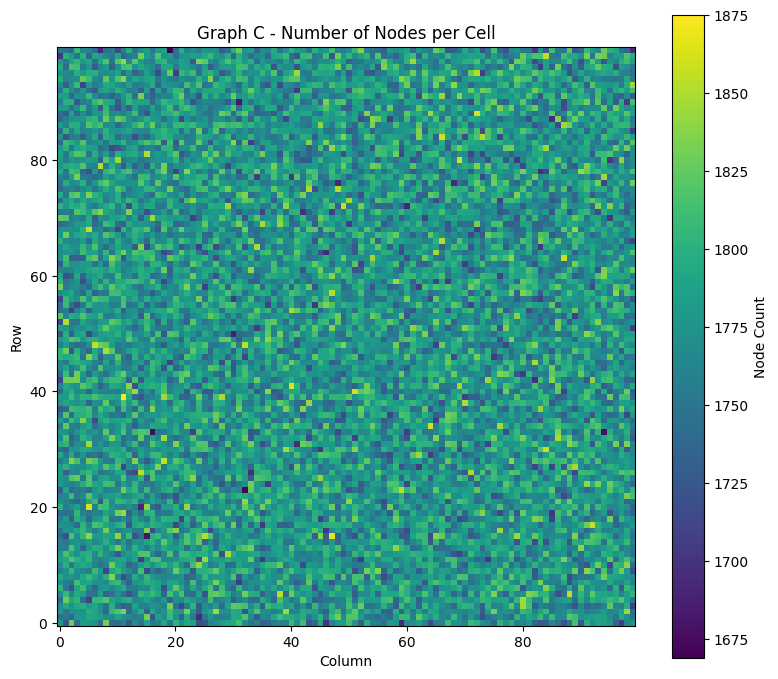

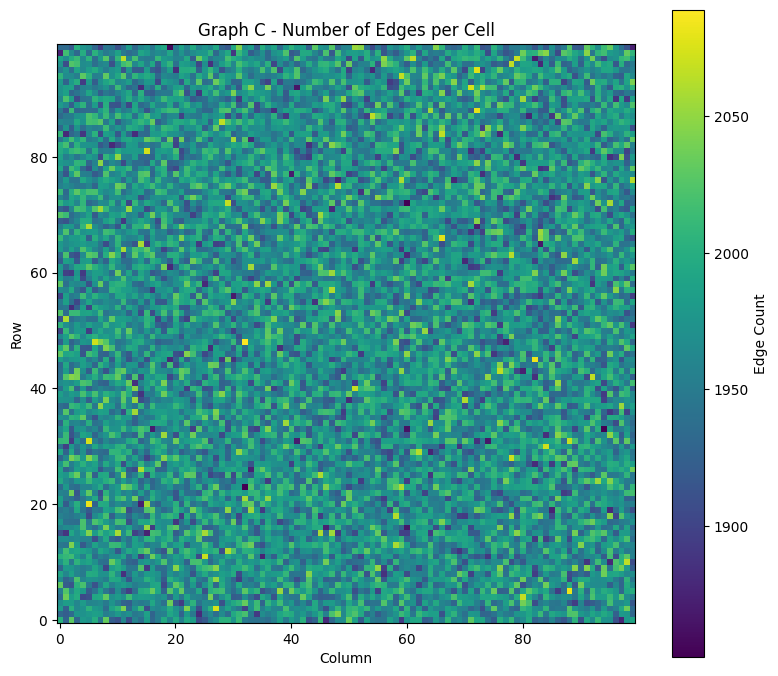

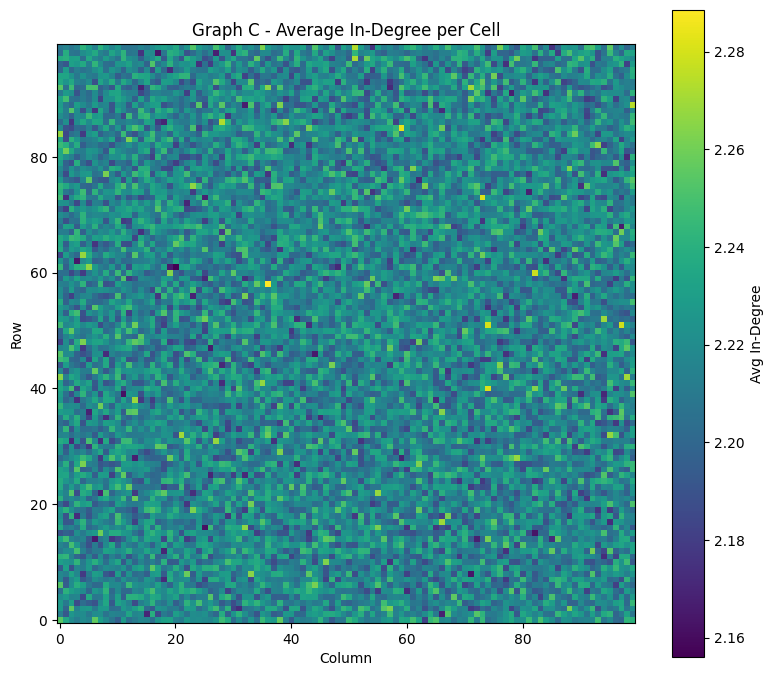

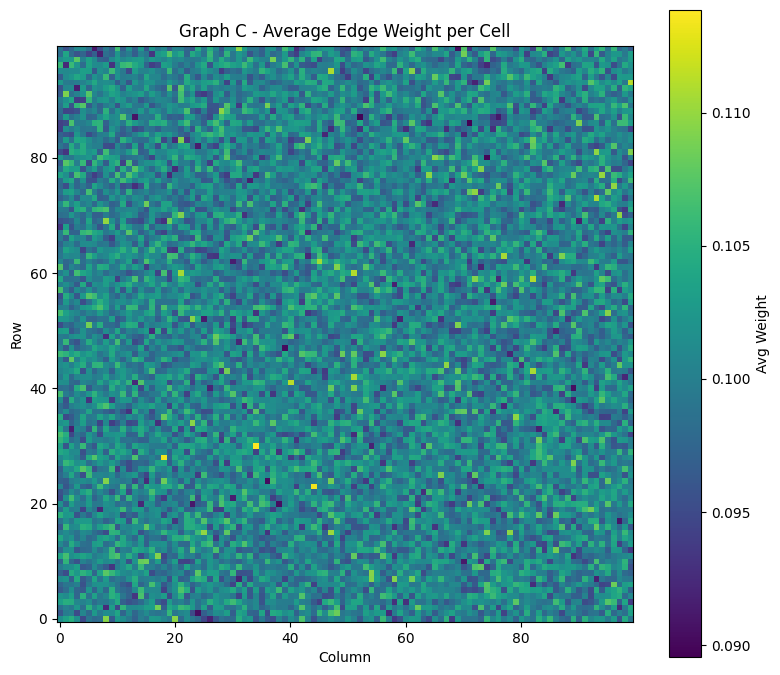

In [32]:
# Visualize heatmaps for Graph C - showing all 100x100 cells
print("Plotting heatmaps for Graph C...")
grids_C = plot_cell_heatmap(cell_to_nodes_C, df_C, n_cells=100, title="Graph C",
                            output_dir=output_dir, prefix="graph_C")

## Comparison Summary [Optional]

In [27]:
# Create a comparison table
comparison = pd.DataFrame({
    'Metric': ['Mean No. of Nodes', 'Mean No. of Edges', 'Mean Avg In-Degree', 'Mean Avg Edge Weight'],
    'Graph A': [
        df_A['num_nodes'].mean(),
        df_A['num_edges'].mean(),
        df_A['avg_in_degree'].mean(),
        df_A['avg_edge_weight'].mean()
    ],
    'Graph C': [
        df_C['num_nodes'].mean(),
        df_C['num_edges'].mean(),
        df_C['avg_in_degree'].mean(),
        df_C['avg_edge_weight'].mean()
    ]
})

print("\n" + "=" * 60)
print("COMPARISON: Graph A vs Graph C")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)


COMPARISON: Graph A vs Graph C
              Metric     Graph A     Graph C
   Mean No. of Nodes 1486.307000 1777.344800
   Mean No. of Edges 1646.964100 1970.136800
  Mean Avg In-Degree    2.216158    2.216946
Mean Avg Edge Weight    0.074908    0.100509


---
# PART 3: [OPTIONAL] Subgraph Analysis (y:35-55, x:45-65)

Extract a subgraph from specific cell range and calculate closeness centrality using NetworKit for better performance.

Skip this section if you only need the 5 Regions Analysis (Part 4).

In [13]:
# Extract subgraph from cells y:35-55, x:45-65
y_min_cell, y_max_cell = 35, 55
x_min_cell, x_max_cell = 45, 65

# Collect all nodes in the specified cell range
subgraph_nodes = []
for (row, col), nodes in cell_to_nodes_A.items():
    if y_min_cell <= row <= y_max_cell and x_min_cell <= col <= x_max_cell:
        subgraph_nodes.extend(nodes)

print(f"Cell range: y=[{y_min_cell}, {y_max_cell}], x=[{x_min_cell}, {x_max_cell}]")
print(f"Number of nodes in subgraph: {len(subgraph_nodes)}")

# Extract subgraph from Graph A
subgraph_A = G_A.subgraph(subgraph_nodes).copy()
print(f"Subgraph nodes: {subgraph_A.number_of_nodes()}")
print(f"Subgraph edges: {subgraph_A.number_of_edges()}")

Cell range: y=[35, 55], x=[45, 65]
Number of nodes in subgraph: 654966
Subgraph nodes: 654966
Subgraph edges: 746799


In [18]:
# Save the subgraph as pickle for future use (output_dir defined in Part 1)
subgraph_path = output_dir / "graph_A_subgraph_y35-55_x45-65.pkl"
with open(subgraph_path, "wb") as f:
    pickle.dump(subgraph_A, f)
print(f"Saved subgraph to {subgraph_path}")

Saved subgraph to ..\data\output\CutGraphs\graph_A_subgraph_y35-55_x45-65.pkl


In [15]:
# Use NetworKit for faster closeness centrality calculation
# NetworKit is much faster than NetworkX for large graphs
import networkit as nk

# Convert NetworkX graph to NetworKit graph
# First, we need to relabel nodes to consecutive integers for NetworKit
node_list = list(subgraph_A.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# Create NetworKit graph
nk_graph = nk.Graph(len(node_list), weighted=True, directed=False)

for u, v, data in subgraph_A.edges(data=True):
    weight = data.get('weight', 1.0)
    nk_graph.addEdge(node_to_idx[u], node_to_idx[v], weight)

print(f"NetworKit graph: {nk_graph.numberOfNodes()} nodes, {nk_graph.numberOfEdges()} edges")

NetworKit graph: 654966 nodes, 746799 edges


In [16]:

# Calculate closeness centrality using NetworKit (much faster than NetworkX)
print("Calculating closeness centrality...")
closeness = nk.centrality.Closeness(nk_graph, False, nk.centrality.ClosenessVariant.Generalized)
closeness.run()

# Get centrality scores and map back to original node IDs
centrality_scores = closeness.scores()
node_centrality = {idx_to_node[idx]: centrality_scores[idx] for idx in range(len(node_list))}

print(f"Closeness centrality calculated for {len(node_centrality)} nodes")
print(f"Min centrality: {min(centrality_scores):.6f}")
print(f"Max centrality: {max(centrality_scores):.6f}")
print(f"Mean centrality: {np.mean(centrality_scores):.6f}")

Calculating closeness centrality...
Closeness centrality calculated for 654966 nodes
Min centrality: 0.000000
Max centrality: 0.064242
Mean centrality: 0.047109


In [ ]:
# Save centrality results
# Save as DataFrame with node positions
centrality_data = []
for node, centrality in node_centrality.items():
    pos = subgraph_A.nodes[node]['pos']
    centrality_data.append({
        'node': node,
        'x': pos[0],
        'y': pos[1],
        'closeness_centrality': centrality
    })

df_centrality = pd.DataFrame(centrality_data)



NameError: name 'output_dir' is not defined

In [20]:
centrality_csv_path = output_dir / "graph_A_subgraph_closeness_centrality.csv"
df_centrality.to_csv(centrality_csv_path, index=False)
print(f"Saved centrality data to {centrality_csv_path}")

# Also save as numpy array (centrality values indexed by node order)
centrality_array = np.array(centrality_scores)
np.save(output_dir / "graph_A_subgraph_closeness_centrality.npy", centrality_array)
print(f"Saved centrality array to {output_dir / 'graph_A_subgraph_closeness_centrality.npy'}")

Saved centrality data to ..\data\output\CutGraphs\graph_A_subgraph_closeness_centrality.csv
Saved centrality array to ..\data\output\CutGraphs\graph_A_subgraph_closeness_centrality.npy


Plotting subgraph with closeness centrality coloring...
Saved plot to ..\data\output\CutGraphs\graph_A_subgraph_closeness_centrality.png


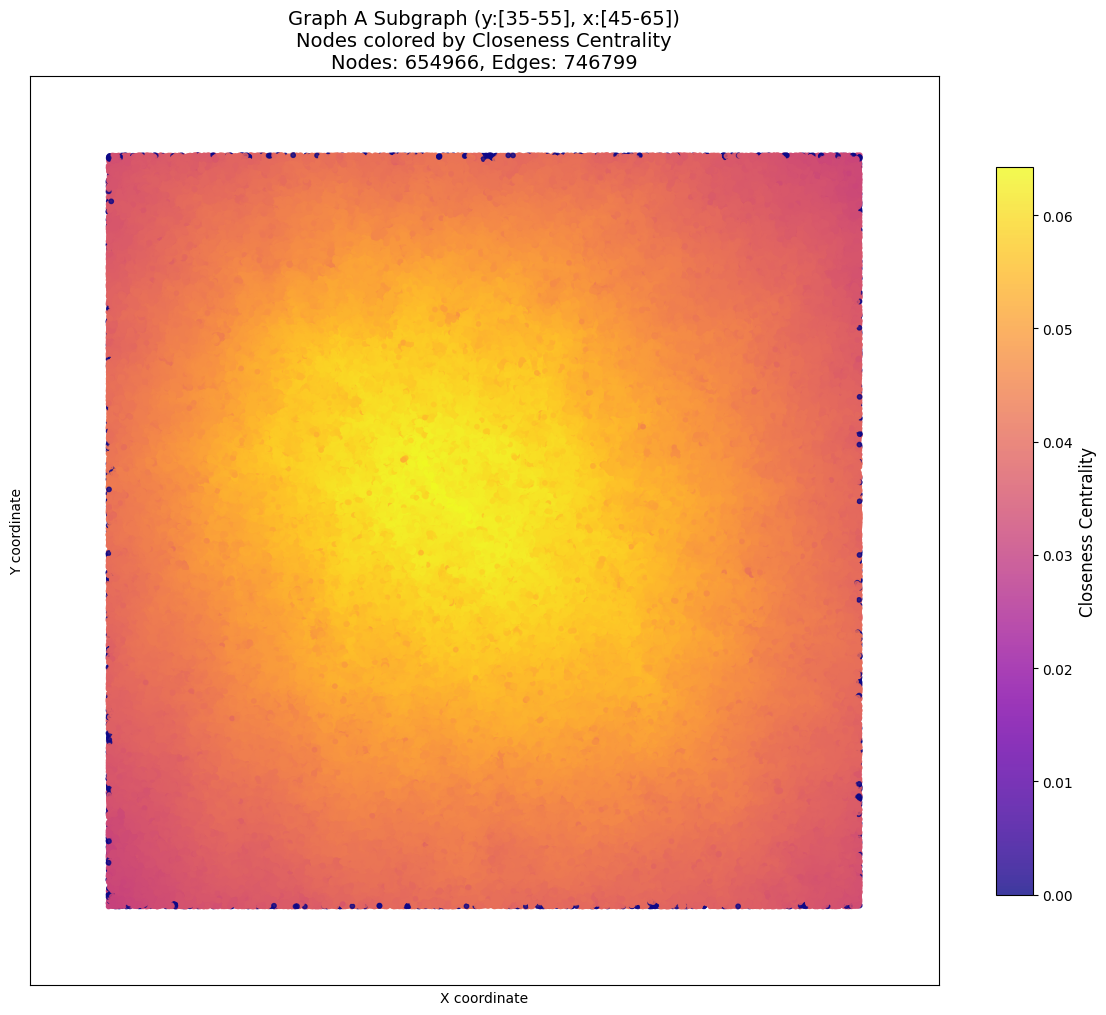

In [21]:
# Plot subgraph with nodes colored by closeness centrality
print("Plotting subgraph with closeness centrality coloring...")

# Get node positions and centrality values in the same order
pos = {node: subgraph_A.nodes[node]['pos'] for node in subgraph_A.nodes()}
node_colors = [node_centrality[node] for node in subgraph_A.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))

# Draw edges first (light gray)
nx.draw_networkx_edges(subgraph_A, pos, alpha=0.3, edge_color='gray', width=0.5, ax=ax)

# Draw nodes colored by closeness centrality
nodes = nx.draw_networkx_nodes(subgraph_A, pos, node_size=10, 
                                node_color=node_colors, cmap='plasma', 
                                alpha=0.8, ax=ax)

# Add colorbar
cbar = plt.colorbar(nodes, ax=ax, shrink=0.8)
cbar.set_label('Closeness Centrality', fontsize=12)

ax.set_title(f'Graph A Subgraph (y:[35-55], x:[45-65])\nNodes colored by Closeness Centrality\n'
             f'Nodes: {subgraph_A.number_of_nodes()}, Edges: {subgraph_A.number_of_edges()}', fontsize=14)
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_aspect('equal')

plt.tight_layout()

# Save the figure
fig.savefig(output_dir / "graph_A_subgraph_closeness_centrality.png", dpi=150)
print(f"Saved plot to {output_dir / 'graph_A_subgraph_closeness_centrality.png'}")

plt.show()

---
# PART 4: 5 Regions Centrality Analysis

**You can jump here directly after running Part 1 (Essential Setup).**

Calculate average closeness and betweenness centrality for 5 regions:
- Center: x:48-52, y:48-52
- Bottom-left corner: x:0-4, y:0-4
- Bottom-right corner: x:95-99, y:0-4
- Top-left corner: x:0-4, y:95-99
- Top-right corner: x:95-99, y:95-99

In [ ]:
# Define 5 regions (5x5 cells each)
regions = {
    'center': {'x_range': (48, 52), 'y_range': (48, 52)},
    'bottom_left': {'x_range': (0, 4), 'y_range': (0, 4)},
    'bottom_right': {'x_range': (95, 99), 'y_range': (0, 4)},
    'top_left': {'x_range': (0, 4), 'y_range': (95, 99)},
    'top_right': {'x_range': (95, 99), 'y_range': (95, 99)},
}

# Function to extract nodes for a region
def get_region_nodes(cell_to_nodes, x_range, y_range):
    """Extract all nodes from cells within the specified x and y ranges."""
    nodes = []
    for (row, col), cell_nodes in cell_to_nodes.items():
        if y_range[0] <= row <= y_range[1] and x_range[0] <= col <= x_range[1]:
            nodes.extend(cell_nodes)
    return nodes

# Print region info
for name, region in regions.items():
    nodes = get_region_nodes(cell_to_nodes_A, region['x_range'], region['y_range'])
    print(f"{name}: x={region['x_range']}, y={region['y_range']}, nodes={len(nodes)}")

In [ ]:
def calculate_region_centrality(G, nodes, region_name):
    """
    Calculate closeness and betweenness centrality for a region's subgraph.
    Uses NetworKit for better performance.
    
    Returns: dict with avg_closeness, avg_betweenness, and detailed stats
    """
    if len(nodes) == 0:
        return {'region': region_name, 'num_nodes': 0, 'num_edges': 0,
                'avg_closeness': 0, 'avg_betweenness': 0}
    
    # Extract subgraph
    subgraph = G.subgraph(nodes).copy()
    n_nodes = subgraph.number_of_nodes()
    n_edges = subgraph.number_of_edges()
    
    print(f"\n--- {region_name} ---")
    print(f"Nodes: {n_nodes}, Edges: {n_edges}")
    
    if n_nodes == 0:
        return {'region': region_name, 'num_nodes': 0, 'num_edges': 0,
                'avg_closeness': 0, 'avg_betweenness': 0}
    
    # Convert to NetworKit
    node_list = list(subgraph.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    
    nk_graph = nk.Graph(len(node_list), weighted=True, directed=False)
    for u, v, data in subgraph.edges(data=True):
        weight = data.get('weight', 1.0)
        nk_graph.addEdge(node_to_idx[u], node_to_idx[v], weight)
    
    # Calculate closeness centrality
    print("  Calculating closeness centrality...")
    closeness = nk.centrality.Closeness(nk_graph, False, nk.centrality.ClosenessVariant.Generalized)
    closeness.run()
    closeness_scores = closeness.scores()
    avg_closeness = np.mean(closeness_scores)
    
    # Calculate betweenness centrality
    print("  Calculating betweenness centrality...")
    betweenness = nk.centrality.Betweenness(nk_graph, normalized=True)
    betweenness.run()
    betweenness_scores = betweenness.scores()
    avg_betweenness = np.mean(betweenness_scores)
    
    print(f"  Avg Closeness: {avg_closeness:.6f}")
    print(f"  Avg Betweenness: {avg_betweenness:.6f}")
    
    return {
        'region': region_name,
        'num_nodes': n_nodes,
        'num_edges': n_edges,
        'avg_closeness': avg_closeness,
        'avg_betweenness': avg_betweenness,
        'closeness_scores': closeness_scores,
        'betweenness_scores': betweenness_scores
    }

In [ ]:
# Calculate centrality for all 5 regions
region_results = []

for name, region in regions.items():
    nodes = get_region_nodes(cell_to_nodes_A, region['x_range'], region['y_range'])
    result = calculate_region_centrality(G_A, nodes, name)
    region_results.append(result)

print("\n" + "=" * 60)
print("All regions processed!")

In [ ]:
# Create summary DataFrame
summary_data = [{
    'Region': r['region'],
    'Nodes': r['num_nodes'],
    'Edges': r['num_edges'],
    'Avg Closeness': r['avg_closeness'],
    'Avg Betweenness': r['avg_betweenness']
} for r in region_results]

df_summary = pd.DataFrame(summary_data)

print("=" * 70)
print("SUMMARY: Average Centrality by Region")
print("=" * 70)
print(df_summary.to_string(index=False))
print("=" * 70)

# Save summary to CSV
summary_path = output_dir / "graph_A_5regions_centrality_summary.csv"
df_summary.to_csv(summary_path, index=False)
print(f"\nSaved summary to {summary_path}")

In [ ]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_names = df_summary['Region'].tolist()
x_pos = np.arange(len(region_names))

# Plot 1: Closeness Centrality
axes[0].bar(x_pos, df_summary['Avg Closeness'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Average Closeness Centrality')
axes[0].set_title('Average Closeness Centrality by Region')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(region_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Betweenness Centrality
axes[1].bar(x_pos, df_summary['Avg Betweenness'], color='coral', alpha=0.8)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Average Betweenness Centrality')
axes[1].set_title('Average Betweenness Centrality by Region')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(region_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save figure
fig.savefig(output_dir / "graph_A_5regions_centrality_comparison.png", dpi=150)
print(f"Saved comparison plot to {output_dir / 'graph_A_5regions_centrality_comparison.png'}")

plt.show()

In [ ]:
# Save detailed centrality scores for each region (numpy arrays)
for result in region_results:
    if result['num_nodes'] > 0:
        region_name = result['region']
        np.save(output_dir / f"graph_A_{region_name}_closeness_scores.npy", 
                np.array(result['closeness_scores']))
        np.save(output_dir / f"graph_A_{region_name}_betweenness_scores.npy", 
                np.array(result['betweenness_scores']))

print("Saved detailed centrality scores for each region:")
for result in region_results:
    if result['num_nodes'] > 0:
        print(f"  - graph_A_{result['region']}_closeness_scores.npy")
        print(f"  - graph_A_{result['region']}_betweenness_scores.npy")

In [ ]:
# Save NetworKit graph for faster future loading
# Also save the node mapping for converting between formats
nk_graph_path = output_dir / "graph_A_subgraph_y35-55_x45-65.nkb"
nk.graphio.NetworkitBinaryWriter().write(nk_graph, str(nk_graph_path))
print(f"Saved NetworKit graph to {nk_graph_path}")

# Save node mapping
mapping_path = output_dir / "graph_A_subgraph_node_mapping.pkl"
with open(mapping_path, "wb") as f:
    pickle.dump({'node_to_idx': node_to_idx, 'idx_to_node': idx_to_node}, f)
print(f"Saved node mapping to {mapping_path}")

print("\n--- Summary of saved files ---")
print(f"1. Subgraph (NetworkX pickle): {subgraph_path}")
print(f"2. Subgraph (NetworKit binary): {nk_graph_path}")
print(f"3. Node mapping: {mapping_path}")
print(f"4. Centrality CSV: {centrality_csv_path}")
print(f"5. Centrality numpy: {output_dir / 'graph_A_subgraph_closeness_centrality.npy'}")
print(f"6. Visualization: {output_dir / 'graph_A_subgraph_closeness_centrality.png'}")

Saved NetworKit graph to ..\data\output\CutGraphs\graph_A_subgraph_y35-55_x45-65.nkb
Saved node mapping to ..\data\output\CutGraphs\graph_A_subgraph_node_mapping.pkl

--- Summary of saved files ---
1. Subgraph (NetworkX pickle): ..\data\output\CutGraphs\graph_A_subgraph_y35-55_x45-65.pkl
2. Subgraph (NetworKit binary): ..\data\output\CutGraphs\graph_A_subgraph_y35-55_x45-65.nkb
3. Node mapping: ..\data\output\CutGraphs\graph_A_subgraph_node_mapping.pkl
4. Centrality CSV: ..\data\output\CutGraphs\graph_A_subgraph_closeness_centrality.csv
5. Centrality numpy: ..\data\output\CutGraphs\graph_A_subgraph_closeness_centrality.npy
6. Visualization: ..\data\output\CutGraphs\graph_A_subgraph_closeness_centrality.png
